In [1]:
!pip install -q scikit-learn seaborn tqdm matplotlib
!pip install scikit-learn seaborn tqdm matplotlib

In [4]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("Total GPU Memory:", torch.cuda.get_device_properties(0).total_memory / 1024**3, "GB")

CUDA Available: True
GPU Name: Tesla T4
Total GPU Memory: 14.56317138671875 GB


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import math

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    roc_auc_score
)

# ============================
# Device
# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [37]:
IMG_SIZE = 224
BATCH_SIZE = 16
LR = 1e-4
NUM_CLASSES = 2
EPOCHS = 30

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 16
LR = 1e-4
NUM_CLASSES = 2

weights = MobileNet_V2_Weights.IMAGENET1K_V1
model = mobilenet_v2(weights=weights)
model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print("Model loaded on:", device)

Model loaded on: cuda


In [6]:
data = np.load("/content/pneumoniamnist.npz")

x_train = data["train_images"]
y_train = data["train_labels"]

x_val   = data["val_images"]
y_val   = data["val_labels"]

x_test  = data["test_images"]
y_test  = data["test_labels"]

from torchvision import transforms
from torchvision.models import MobileNet_V2_Weights

weights = MobileNet_V2_Weights.IMAGENET1K_V1

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
])


In [7]:
class PneumoniaDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels.squeeze()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.uint8)
        label = self.labels[idx]
        image = transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = PneumoniaDataset(x_train, y_train)
val_dataset   = PneumoniaDataset(x_val, y_val)
test_dataset  = PneumoniaDataset(x_test, y_test)
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=2,
                        pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [8]:
model = mobilenet_v2(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [9]:
patience = 5
best_val_loss = float("inf")
counter = 0


In [10]:
metric_names = [
    "loss", "accuracy", "precision", "recall",
    "f1_score", "specificity", "sensitivity",
    "mcc", "auc"
]

train_metrics_history = {m: [] for m in metric_names}
val_metrics_history   = {m: [] for m in metric_names}


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNetV2
model = mobilenet_v2(weights=weights)

# Replace classifier
model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)

model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [12]:
import numpy as np
import math
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

EPOCHS = 30
patience = 5
best_val_loss = float("inf")
counter = 0

metric_names = [
    "loss", "accuracy", "precision", "recall",
    "f1_score", "specificity", "sensitivity",
    "mcc", "auc"
]

train_metrics_history = {m: [] for m in metric_names}
val_metrics_history = {m: [] for m in metric_names}

# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(EPOCHS):

    # ============================
    # TRAIN
    # ============================
    model.train()
    train_loss = 0
    train_preds, train_labels, train_probs = [], [], []

    for images, labels in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{EPOCHS}]"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())
        train_probs.extend(probs.detach().cpu().numpy())

    train_loss /= len(train_loader)

    tn, fp, fn, tp = confusion_matrix(train_labels, train_preds).ravel()

    train_metrics = {
        "loss": train_loss,
        "accuracy": accuracy_score(train_labels, train_preds),
        "precision": precision_score(train_labels, train_preds, zero_division=0),
        "recall": recall_score(train_labels, train_preds, zero_division=0),
        "f1_score": f1_score(train_labels, train_preds, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8),
        "sensitivity": tp / (tp + fn + 1e-8),
        "mcc": matthews_corrcoef(train_labels, train_preds),
        "auc": roc_auc_score(train_labels, train_probs)
    }

    # ============================
    # VALIDATION
    # ============================
    model.eval()
    val_loss = 0
    val_preds, val_labels, val_probs = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())

    val_loss /= len(val_loader)

    tn, fp, fn, tp = confusion_matrix(val_labels, val_preds).ravel()

    val_metrics = {
        "loss": val_loss,
        "accuracy": accuracy_score(val_labels, val_preds),
        "precision": precision_score(val_labels, val_preds, zero_division=0),
        "recall": recall_score(val_labels, val_preds, zero_division=0),
        "f1_score": f1_score(val_labels, val_preds, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8),
        "sensitivity": tp / (tp + fn + 1e-8),
        "mcc": matthews_corrcoef(val_labels, val_preds),
        "auc": roc_auc_score(val_labels, val_probs)
    }

    # ============================
    # PRINT METRICS
    # ============================
    print("\nTrain Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))
    print("Val Metrics   - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()]))

    # Store history
    for k in metric_names:
        train_metrics_history[k].append(train_metrics[k])
        val_metrics_history[k].append(val_metrics[k])

    # ============================
    # EARLY STOPPING
    # ============================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Validation improved. Model saved.")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

    if counter >= patience:
        print("Early stopping triggered.")
        break

Training Epoch [1/30]: 100%|██████████| 243/243 [00:18<00:00, 12.96it/s]



Train Metrics - loss: 0.1402, accuracy: 0.9426, precision: 0.9742, recall: 0.9616, f1_score: 0.9679, specificity: 0.7706, sensitivity: 0.9616, mcc: 0.6977, auc: 0.9652
Val Metrics   - loss: 0.1193, accuracy: 0.9561, precision: 0.9507, recall: 0.9923, f1_score: 0.9711, specificity: 0.8519, sensitivity: 0.9923, mcc: 0.8838, auc: 0.9916
Validation improved. Model saved.


Training Epoch [2/30]: 100%|██████████| 243/243 [00:16<00:00, 14.99it/s]



Train Metrics - loss: 0.0466, accuracy: 0.9853, precision: 0.9914, recall: 0.9923, f1_score: 0.9918, specificity: 0.9227, sensitivity: 0.9923, mcc: 0.9181, auc: 0.9962
Val Metrics   - loss: 0.1450, accuracy: 0.9447, precision: 0.9348, recall: 0.9949, f1_score: 0.9639, specificity: 0.8000, sensitivity: 0.9949, mcc: 0.8536, auc: 0.9946
No improvement (1/5)


Training Epoch [3/30]: 100%|██████████| 243/243 [00:16<00:00, 14.64it/s]


...


Train Metrics - loss: 0.0125, accuracy: 0.9959, precision: 0.9980, recall: 0.9974, f1_score: 0.9977, specificity: 0.9820, sensitivity: 0.9974, mcc: 0.9771, auc: 0.9997
Val Metrics   - loss: 0.1208, accuracy: 0.9580, precision: 0.9576, recall: 0.9871, f1_score: 0.9722, specificity: 0.8741, sensitivity: 0.9871, mcc: 0.8887, auc: 0.9941
No improvement (3/5)


Training Epoch [7/30]: 100%|██████████| 243/243 [00:16<00:00, 14.46it/s]



Train Metrics - loss: 0.0103, accuracy: 0.9961, precision: 0.9980, recall: 0.9977, f1_score: 0.9979, specificity: 0.9820, sensitivity: 0.9977, mcc: 0.9785, auc: 0.9998
Val Metrics   - loss: 0.1165, accuracy: 0.9599, precision: 0.9600, recall: 0.9871, f1_score: 0.9734, specificity: 0.8815, sensitivity: 0.9871, mcc: 0.8938, auc: 0.9947
No improvement (4/5)


Training Epoch [8/30]: 100%|██████████| 243/243 [00:16<00:00, 14.31it/s]



Train Metrics - loss: 0.0053, accuracy: 0.9982, precision: 0.9991, recall: 0.9989, f1_score: 0.9990, specificity: 0.9923, sensitivity: 0.9989, mcc: 0.9900, auc: 1.0000
Val Metrics   - loss: 0.1239, accuracy: 0.9637, precision: 0.9602, recall: 0.9923, f1_score: 0.9760, specificity: 0.8815, sensitivity: 0.9923, mcc: 0.9042, auc: 0.9948
No improvement (5/5)
Early stopping triggered.


/tmp/ipython-input-1521893181.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))



Classification Report:

              precision    recall  f1-score   support

           0     0.9915    0.4957    0.6610       234
           1     0.7673    0.9974    0.8673       390

    accuracy                         0.8093       624
   macro avg     0.8794    0.7466    0.7642       624
weighted avg     0.8513    0.8093    0.7899       624



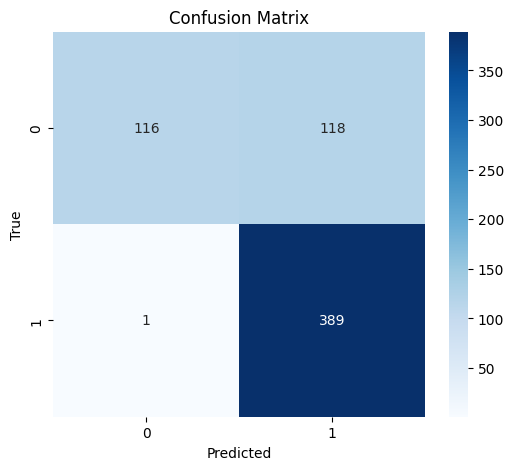

In [13]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# ============================
# Final Test Evaluation
# ============================

test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

print("\nClassification Report:\n")
print(classification_report(test_labels, test_preds, digits=4))

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

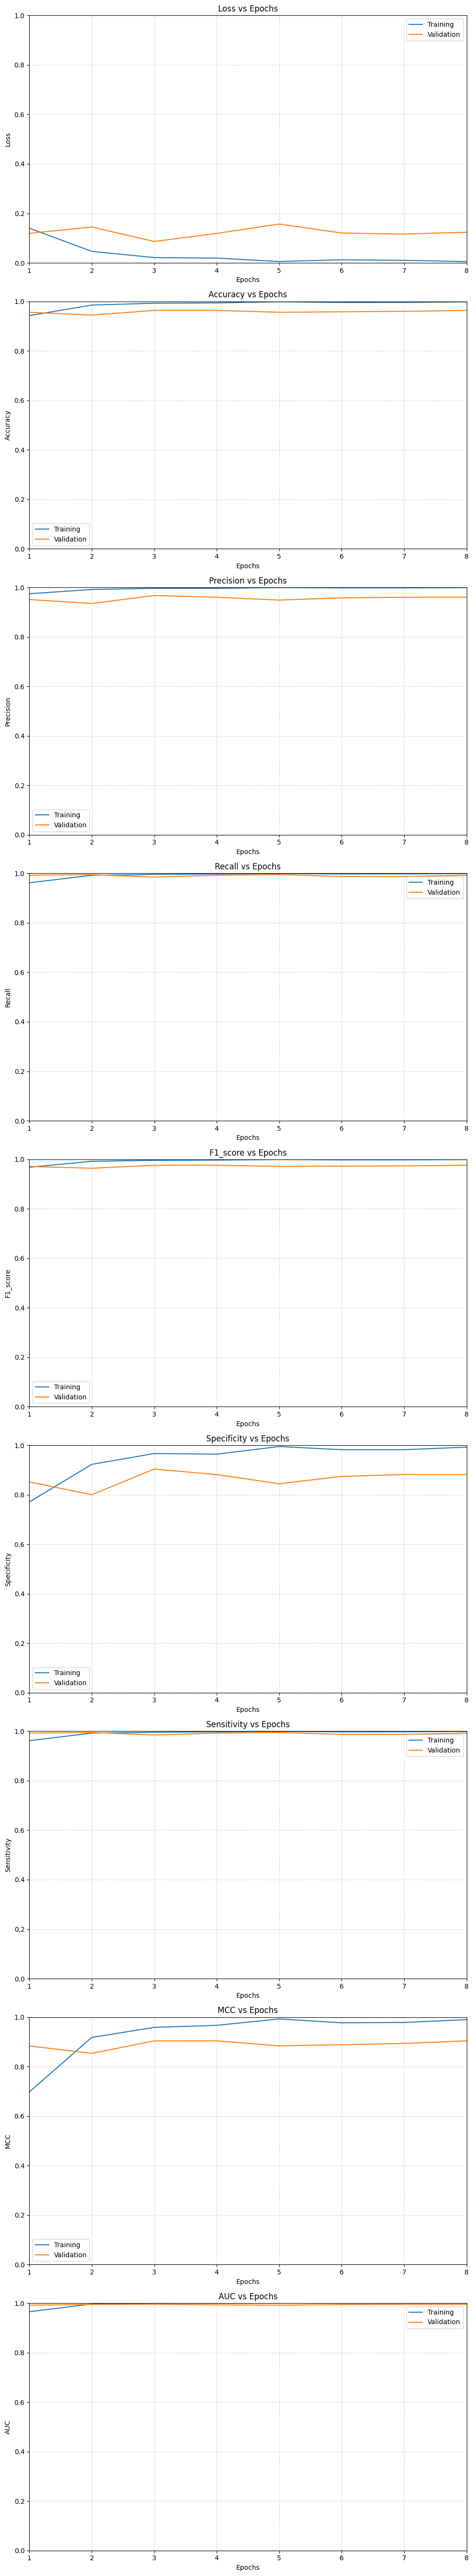

In [14]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))
    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name in ("auc", "mcc"):
            ax.set_ylabel(metric_name.upper())
            ax.set_title(f"{metric_name.upper()} vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)
        # Adjust xlim to avoid identical low and high limits.
        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()

plot_metrics(train_metrics_history, val_metrics_history, metric_names)